# λ(t) Time Series Analysis

Analysis of Lyapunov exponent time series `λ(t)` and its standard deviation across initial conditions, at a fixed critical value `a = 0.7616`.

**Workflow:**
1. Imports & Setup
2. Global Parameters
3. Load raw samples → compute mean and Std(λ(t))
4. Plot λ(t) per L
5. Plot Std(λ(t)) per L
6. Std(λ) vs log(t) — all L on one plot
7. Zoomed Std(λ) in peak window [t_min, t_max]
8. Save peak-window data for collapse
9. Collapsed Std(λ) vs t/L^z (zoomed and full)
10. Collapsed Std(λ) vs log(t/L^z)
11. Publication figure: log(t) main panel + collapsed inset


---
## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import matplotlib as mpl

def make_path_exist(filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

def save_simple_dict_to_csv(data: dict, filepath: str):
    """Save {float -> float} dict to CSV with columns 'aval' and 'value'."""
    make_path_exist(filepath)
    df = pd.DataFrame(sorted(data.items()), columns=["t_step", "value"])
    df.to_csv(filepath, index=False)

plt.rcParams.update({
    "axes.labelsize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
})

def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 16
    plt.rcParams["axes.labelsize"] = 24
    plt.rcParams["legend.fontsize"] = 18

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()

---
## 2. Global Parameters

In [2]:
J   = 1
tau = 1 * J

N_val = 4

num_unit_cells_vals = [8, 16, 32, 64, 128]
num_uc = len(num_unit_cells_vals)

# Blue palette: light -> dark, one colour per system size
blue_colors = [mcolors.to_rgba(c) for c in
               plt.cm.Blues(np.linspace(0.35, 0.85, num_uc))]

num_initial_conds = 1000

a_vals = [0.7563, 0.7575, 0.7588]   # single critical value analysed here

averaging_window      = 1          # keep all time steps (no trimming)
skip_fract            = 1 - averaging_window
averaging_window_name = str(round(averaging_window, 3)).replace(".", "p")

z_val      = 1.7
z_val_name = str(z_val).replace(".", "p")

# Window used to isolate the peak region of Std(λ)
peak_frac_lims = [1/30, 9/10]

parent_data_path = "/Volumes/ExternalData" 

---
## 3. Load Raw Samples → Compute Mean λ(t) and Std(λ(t))

In [68]:
# collected_lambda_series[L][a_val]     -> np.array of shape (T,)  mean over ICs
# collected_lambda_STD_series[L][a_val] -> np.array of shape (T,)  std  over ICs
collected_lambda_series     = {}
collected_lambda_STD_series = {}

for num_unit_cells in num_unit_cells_vals:
    L = num_unit_cells * N_val
    print(f"L = {L}")

    n        = int(round(L ** z_val))
    num_skip = int(round(skip_fract * n)) + 1   # matches Julia 1-indexed slice
    T        = n - num_skip                      # number of retained time steps

    collected_lambda_series[L]     = {}
    collected_lambda_STD_series[L] = {}

    for a_val in a_vals:
        a_name = str(a_val).replace(".", "p")
        print(f"  a = {a_val}")

        all_ic = np.zeros((num_initial_conds, T))

        for ic in range(1, num_initial_conds + 1):
            filepath = (
                f"{parent_data_path}/spin_dists_per_time/N{N_val}/a{a_name}/IC1/L{L}/"
                f"N{N_val}_a{a_name}_IC1_L{L}_z{z_val_name}_sample{ic}.csv"
            )
            df = pd.read_csv(filepath, usecols=["lambda"])
            all_ic[ic - 1] = df["lambda"].values[num_skip:n]

        collected_lambda_series[L][a_val]     = all_ic.mean(axis=0)
        collected_lambda_STD_series[L][a_val] = all_ic.std(axis=0, ddof=1)

        # --- Save summary CSVs for this L ---
        out_dir = (
            f"data/lambda_series/N{N_val}/a{a_name}/IC{num_initial_conds}/L{L}/"
        )
        os.makedirs(out_dir, exist_ok=True)

        fname  = f"N{N_val}_a{a_name}_IC{num_initial_conds}_L{L}_z{z_val_name}"

        pd.DataFrame({
            "mean_lambda": collected_lambda_series[L][a_val],
            "std_lambda":  collected_lambda_STD_series[L][a_val],
        }).to_csv(out_dir + fname + ".csv", index=False)

        print(f"  Saved CSVs for L={L}")

print("Done.")

L = 32
  a = 0.7565


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/ExternalData/spin_dists_per_time/N4/a0p7565/IC1/L32/N4_a0p7565_IC1_L32_z1p7_sample1.csv'

In [3]:
collected_lambda_series     = {}
collected_lambda_STD_series = {}

for num_unit_cells in num_unit_cells_vals:
    L = num_unit_cells * N_val
    print(f"Loading L = {L}")

    collected_lambda_series[L]     = {}
    collected_lambda_STD_series[L] = {}

    for a_val in a_vals:
        a_name = str(a_val).replace(".", "p")
        out_dir = (
            f"data/lambda_series/N{N_val}/a{a_name}/IC{num_initial_conds}/L{L}/"
        )

        fname  = f"N{N_val}_a{a_name}_IC{num_initial_conds}_L{L}_z{z_val_name}"

        df = pd.read_csv(out_dir + fname + ".csv")
        collected_lambda_series[L][a_val]     = df["mean_lambda"].values
        collected_lambda_STD_series[L][a_val] = df["std_lambda"].values

print("Done.")

Loading L = 32
Loading L = 64
Loading L = 128
Loading L = 256
Loading L = 512
Done.


---
## 4. Plot λ(t) per L

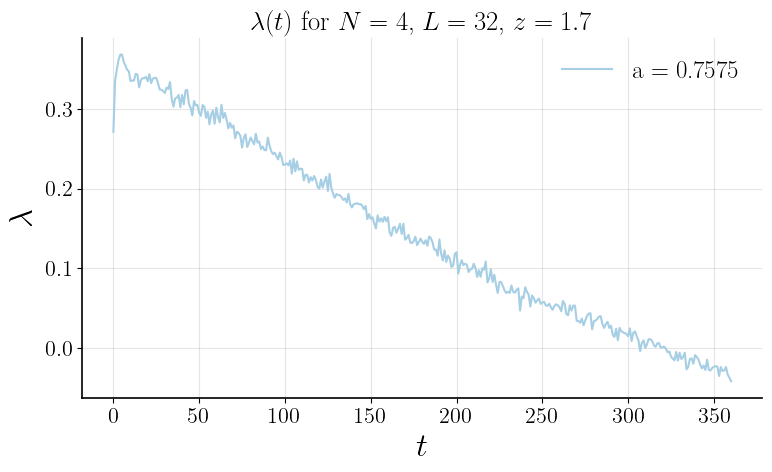

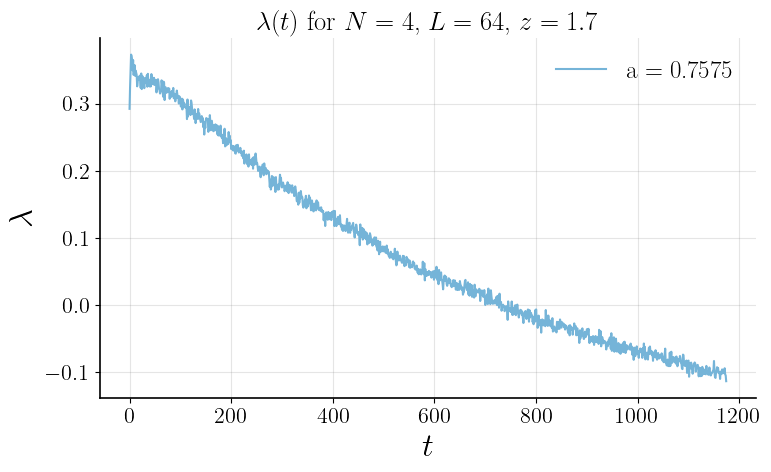

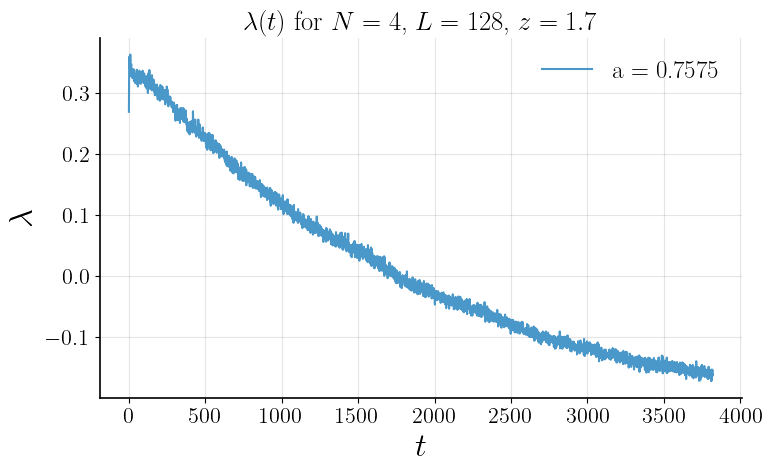

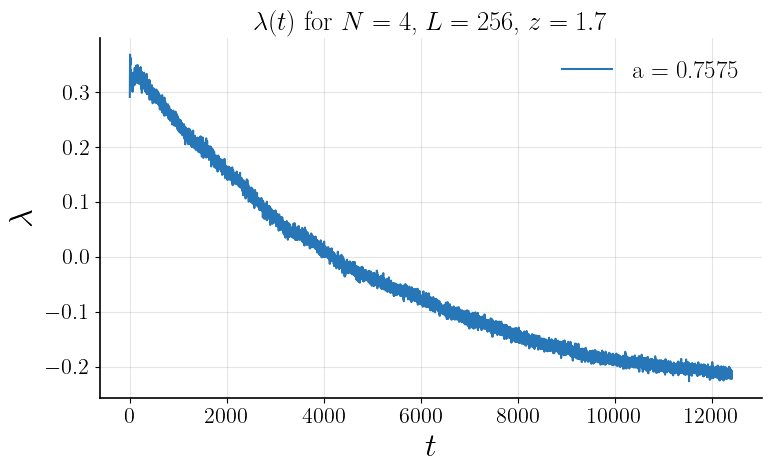

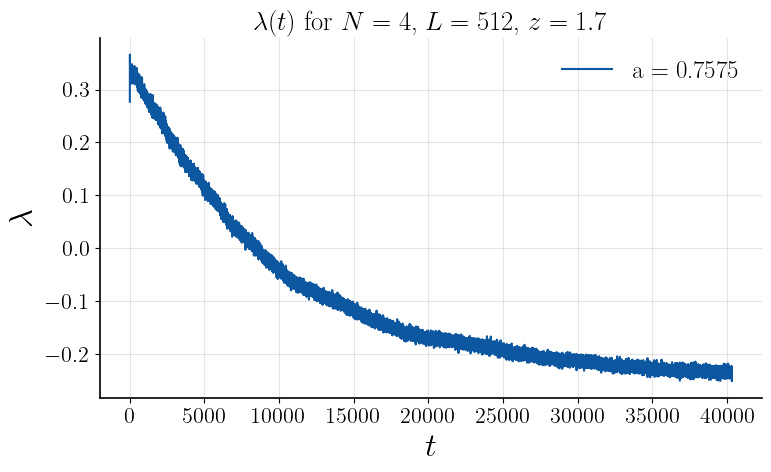

In [ ]:


for a_val in a_vals:
    for i, num_unit_cells in enumerate(num_unit_cells_vals):
        L = num_unit_cells * N_val
        c = blue_colors[i]

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title(rf"$\lambda(t)$ for $N={N_val}$, $L={L}$, $z={z_val}$, $a={a_val}$")
        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$\lambda(t)$")

        ax.plot(collected_lambda_series[L][a_val], color=c")

        ax.legend()
        fig.tight_layout()
        plt.show()

---
## 5. Plot Std(λ(t)) per L

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/L32/std_lambda_per_t_N4_a0p7563_IC1000_L32_z1p7.png


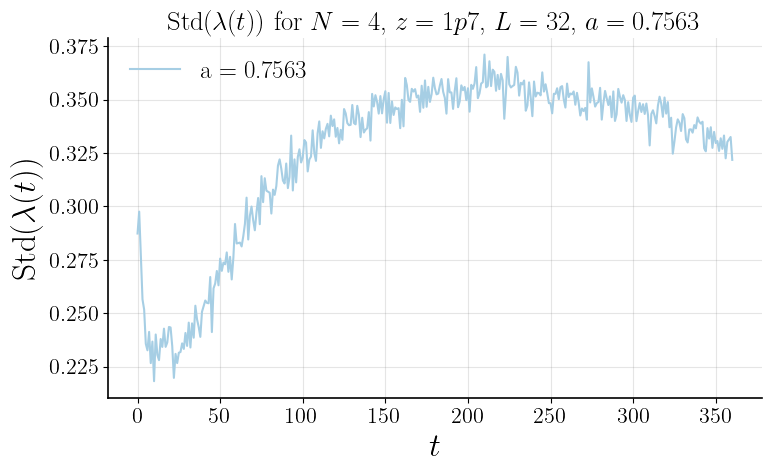

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/L64/std_lambda_per_t_N4_a0p7563_IC1000_L64_z1p7.png


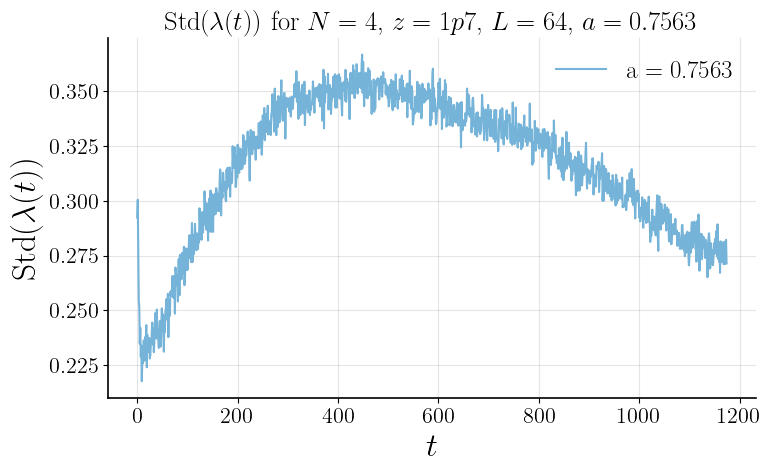

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/L128/std_lambda_per_t_N4_a0p7563_IC1000_L128_z1p7.png


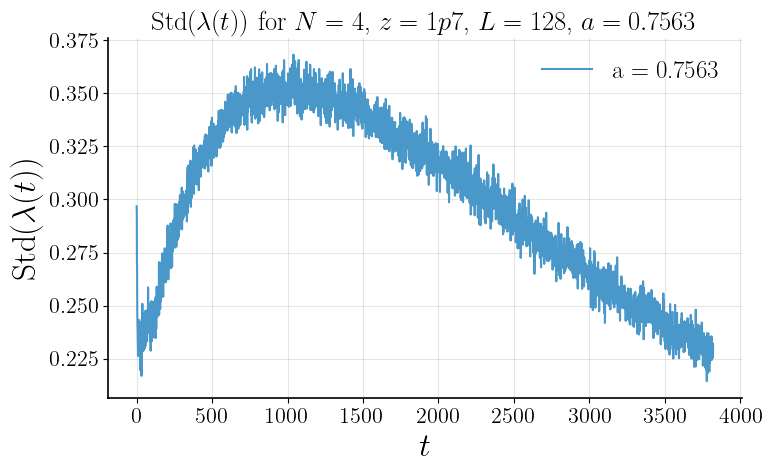

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/L256/std_lambda_per_t_N4_a0p7563_IC1000_L256_z1p7.png


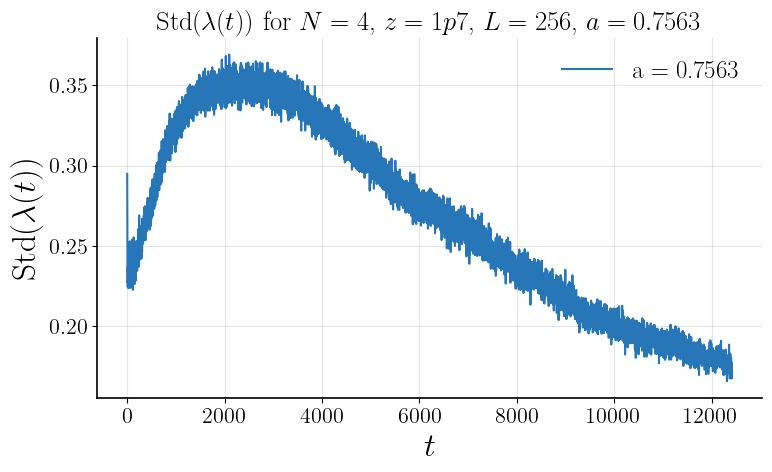

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/L512/std_lambda_per_t_N4_a0p7563_IC1000_L512_z1p7.png


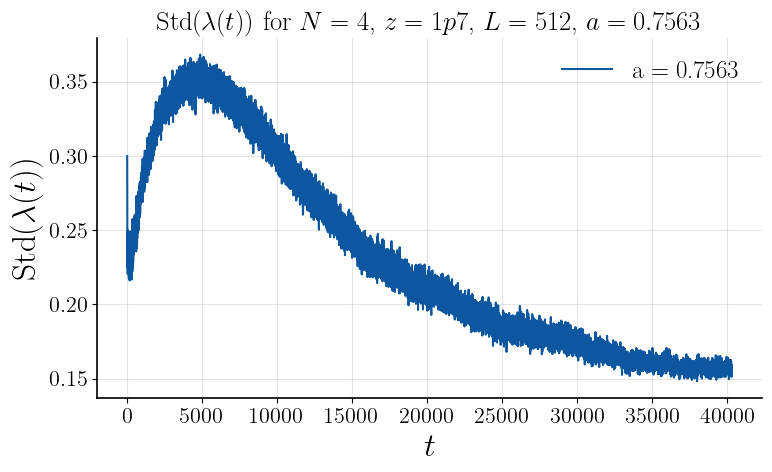

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/L32/std_lambda_per_t_N4_a0p7575_IC1000_L32_z1p7.png


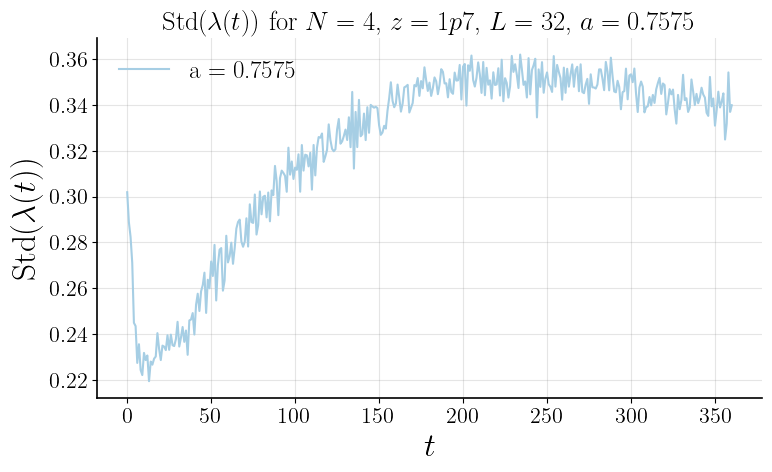

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/L64/std_lambda_per_t_N4_a0p7575_IC1000_L64_z1p7.png


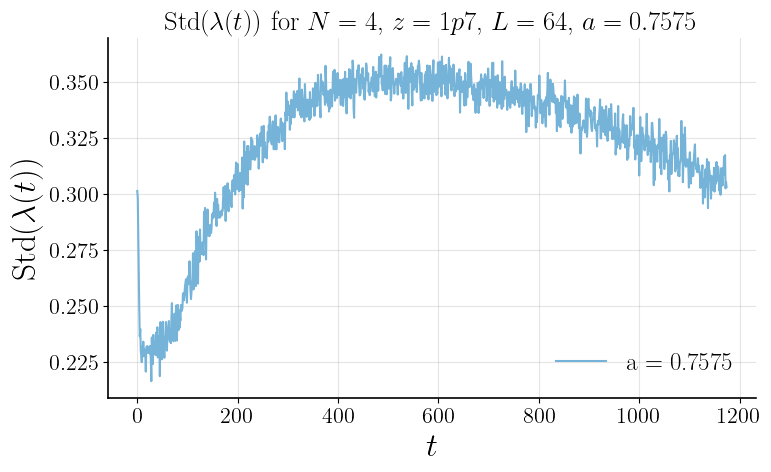

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/L128/std_lambda_per_t_N4_a0p7575_IC1000_L128_z1p7.png


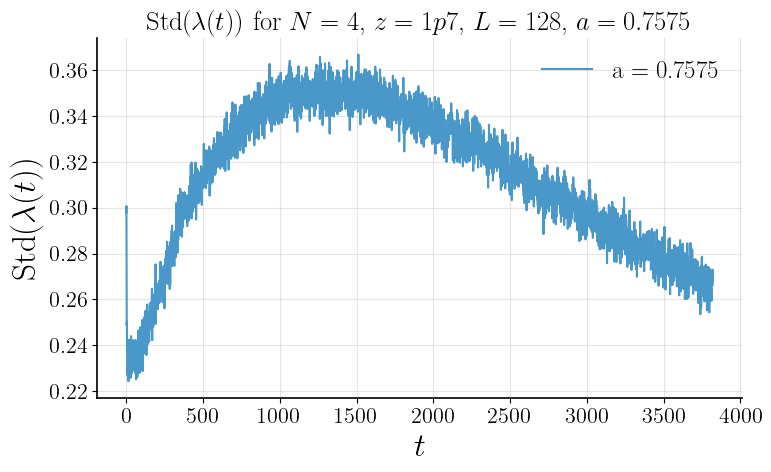

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/L256/std_lambda_per_t_N4_a0p7575_IC1000_L256_z1p7.png


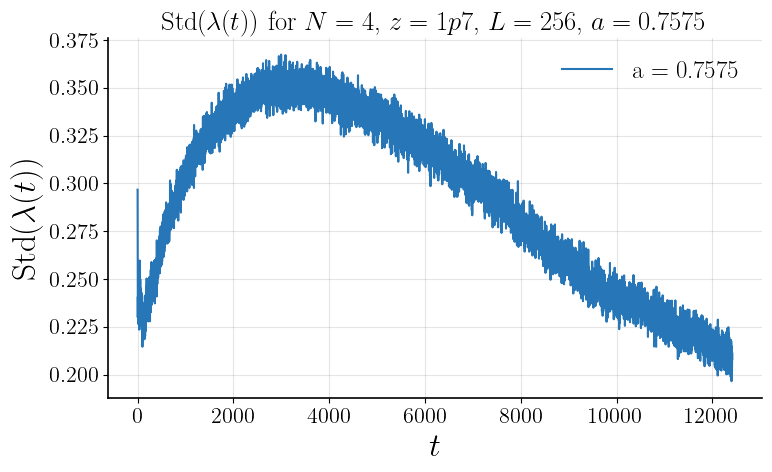

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/L512/std_lambda_per_t_N4_a0p7575_IC1000_L512_z1p7.png


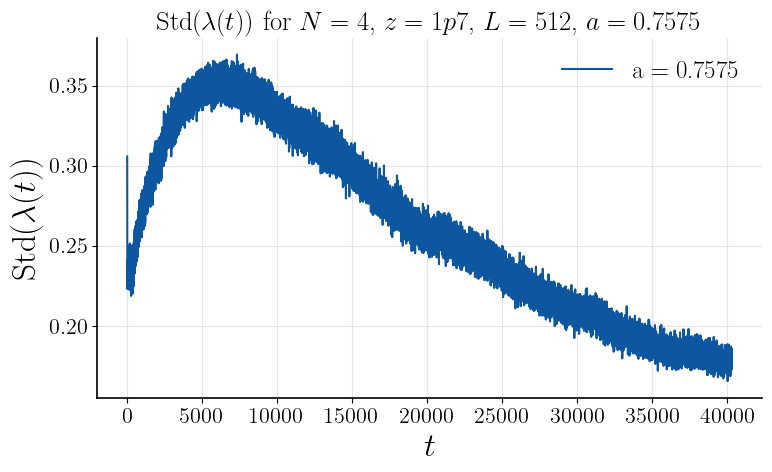

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/L32/std_lambda_per_t_N4_a0p7588_IC1000_L32_z1p7.png


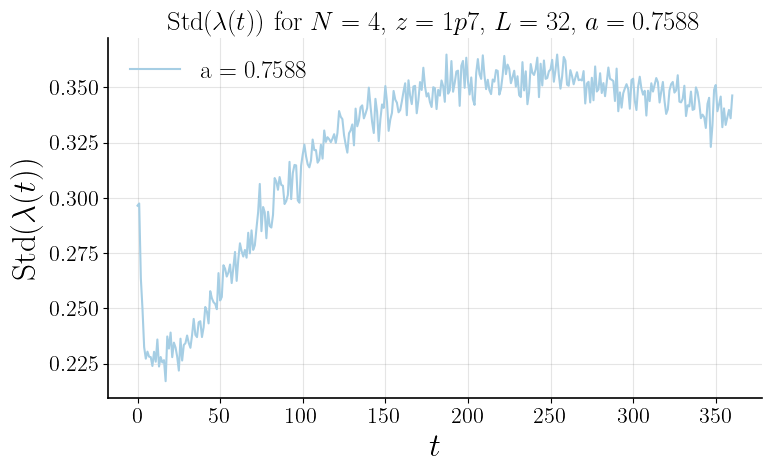

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/L64/std_lambda_per_t_N4_a0p7588_IC1000_L64_z1p7.png


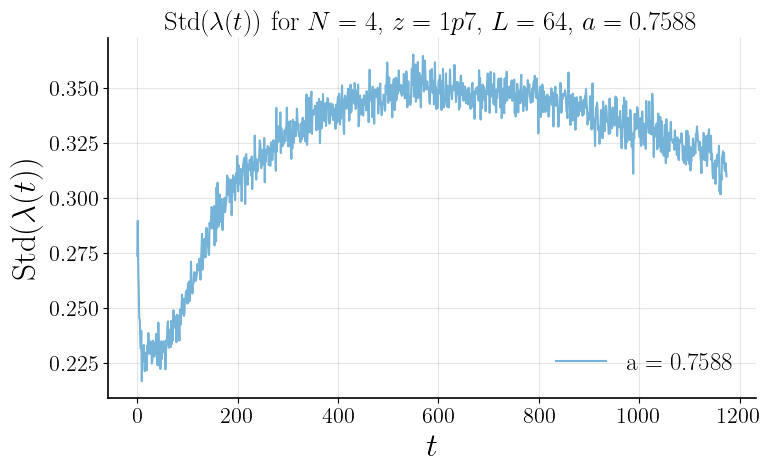

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/L128/std_lambda_per_t_N4_a0p7588_IC1000_L128_z1p7.png


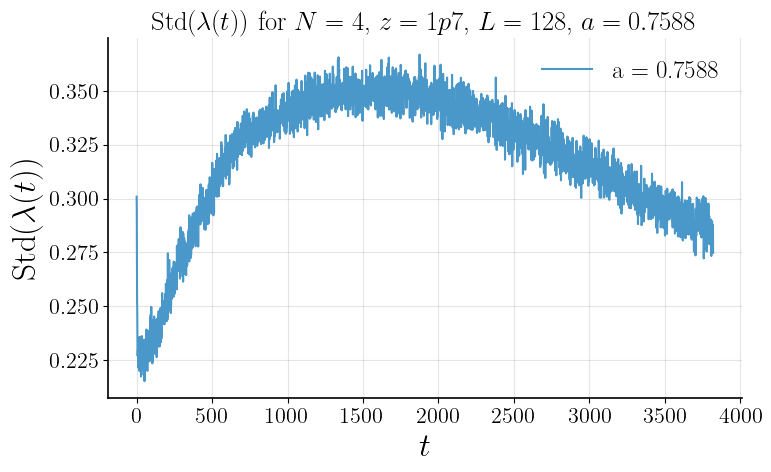

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/L256/std_lambda_per_t_N4_a0p7588_IC1000_L256_z1p7.png


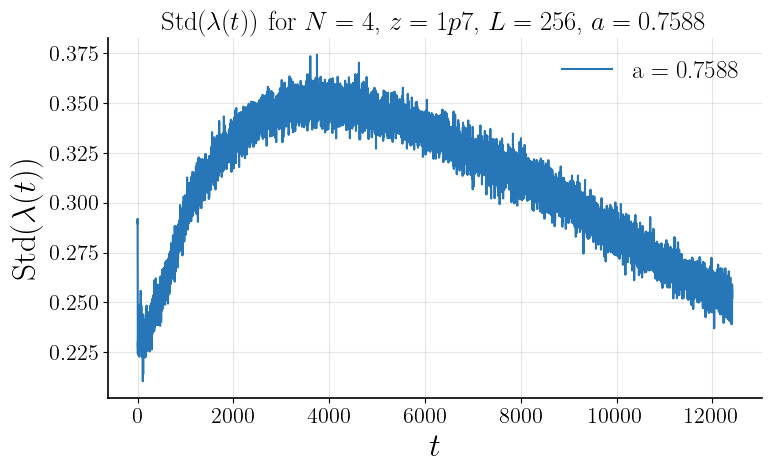

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/L512/std_lambda_per_t_N4_a0p7588_IC1000_L512_z1p7.png


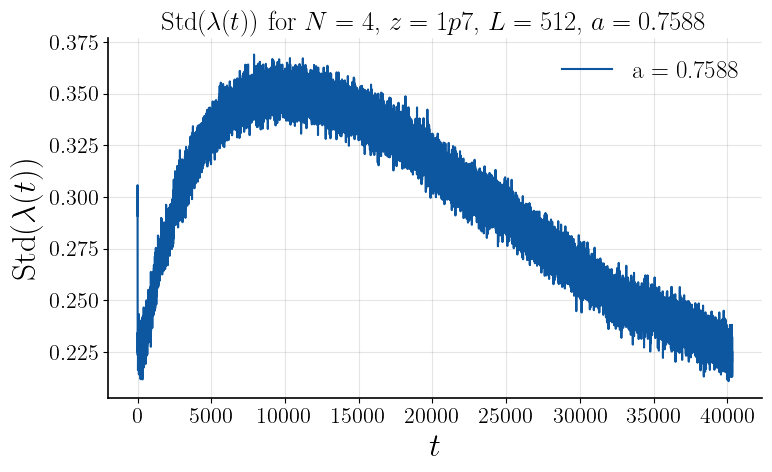

In [4]:

for a_val in a_vals:
    a_val_name = str(a_val).replace(".", "p")
    for i, num_unit_cells in enumerate(num_unit_cells_vals):
        L = num_unit_cells * N_val
        c = blue_colors[i]

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title(rf"$\mathrm{{Std}}(\lambda(t))$ for $N={N_val}$, $z={z_val_name}$, $L={L}$, $a={a_val}$")
        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

        ax.plot(collected_lambda_STD_series[L][a_val], color=c, label=f"a = {a_val}")

        ax.legend()

        out = (
            f"figs/lambda_per_t/N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L}/"
            f"std_lambda_per_t_N{N_val}_a{a_val_name}"
            f"_IC{num_initial_conds}_L{L}_z{z_val_name}.png"
        )
        make_path_exist(out)
        fig.tight_layout()
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")
        plt.show()

---
## 6. Std(λ) vs log(t) — All L on One Plot

This is the **main log(t) panel** reused later as the base for the publication inset figure.

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/LSeveral/std_lambda_per_log_t_N4_a0p7563_IC1000_z1p7.png


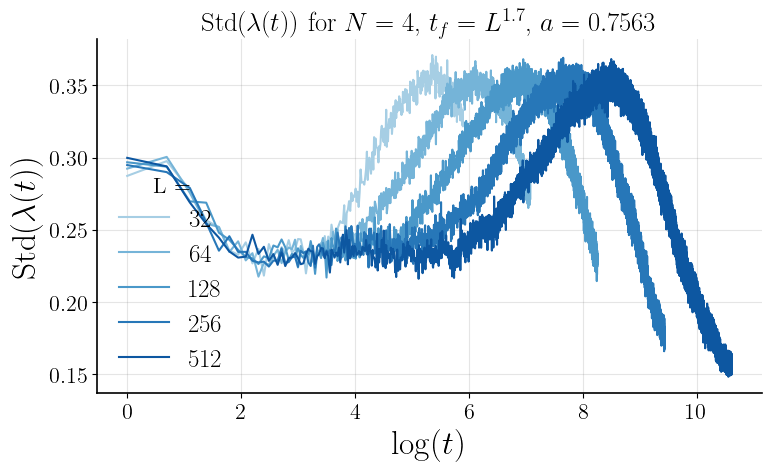

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/LSeveral/std_lambda_per_log_t_N4_a0p7575_IC1000_z1p7.png


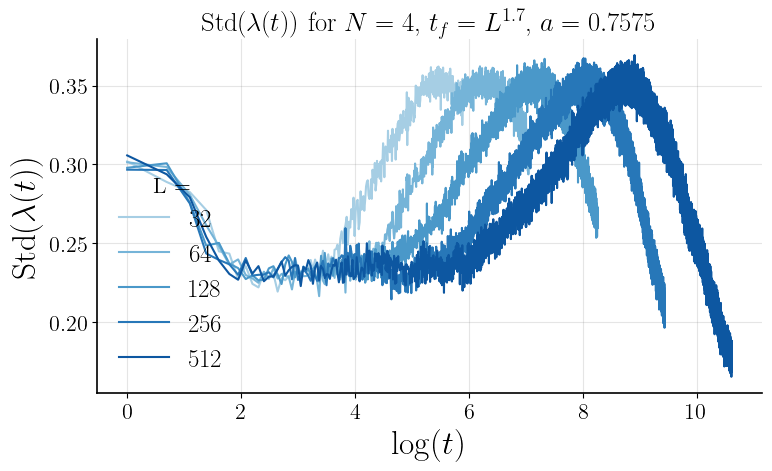

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/LSeveral/std_lambda_per_log_t_N4_a0p7588_IC1000_z1p7.png


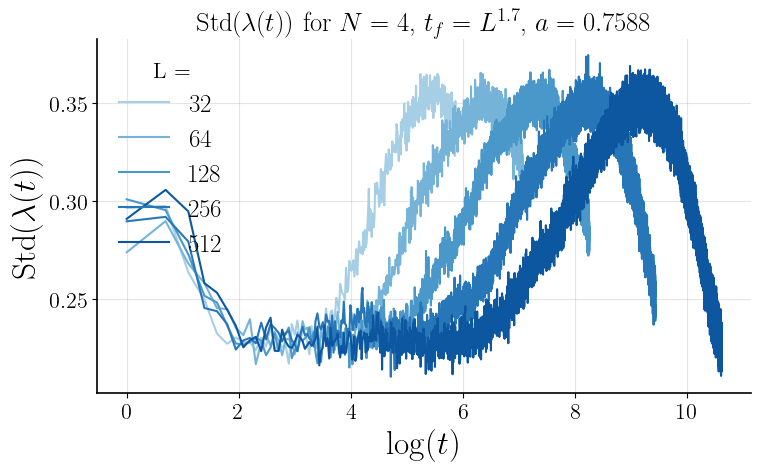

In [5]:

for a_val in a_vals:
    a_val_name = str(a_val).replace(".", "p")
    fig_log, ax_log = plt.subplots(figsize=(8, 5))
    ax_log.set_title(
        rf"$\mathrm{{Std}}(\lambda(t))$ for $N={N_val}$, $t_f = L^{{{z_val}}}$, $a={a_val}$"
    )
    ax_log.set_xlabel(r"$\log(t)$")
    ax_log.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

    for i, num_unit_cells in enumerate(num_unit_cells_vals):
        L = num_unit_cells * N_val
        c = blue_colors[i]
        y  = collected_lambda_STD_series[L][a_val]
        ax_log.plot(np.log(np.arange(1, len(y) + 1)), y,
                    color=c, label=str(L))

    ax_log.legend(title="L =")

    out = (
        f"figs/lambda_per_t/N{N_val}/a{a_val_name}/IC{num_initial_conds}/LSeveral/"
        f"std_lambda_per_log_t_N{N_val}_a{a_val_name}"
        f"_IC{num_initial_conds}_z{z_val_name}.png"
    )
    make_path_exist(out)
    fig_log.tight_layout()
    fig_log.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()

---
## 7. Zoomed Std(λ) in Peak Window

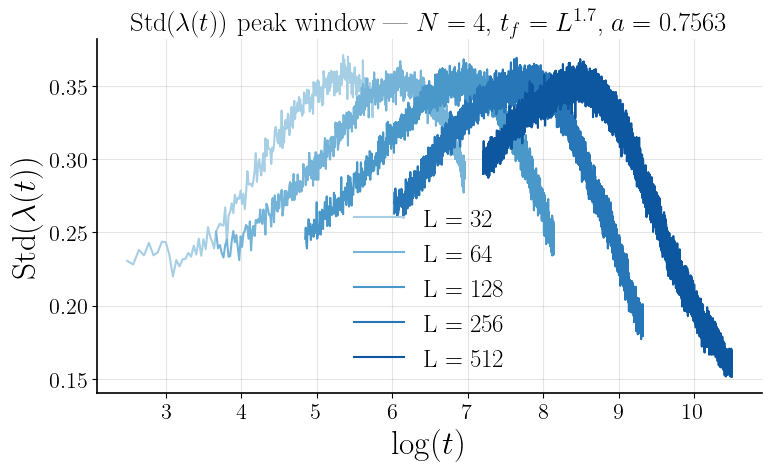

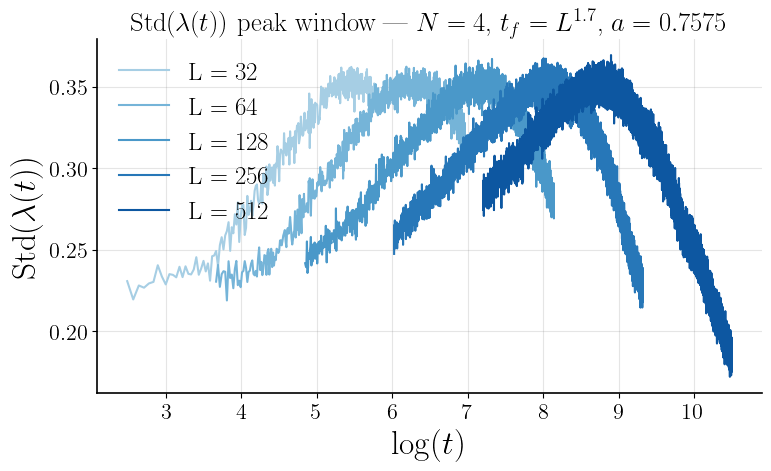

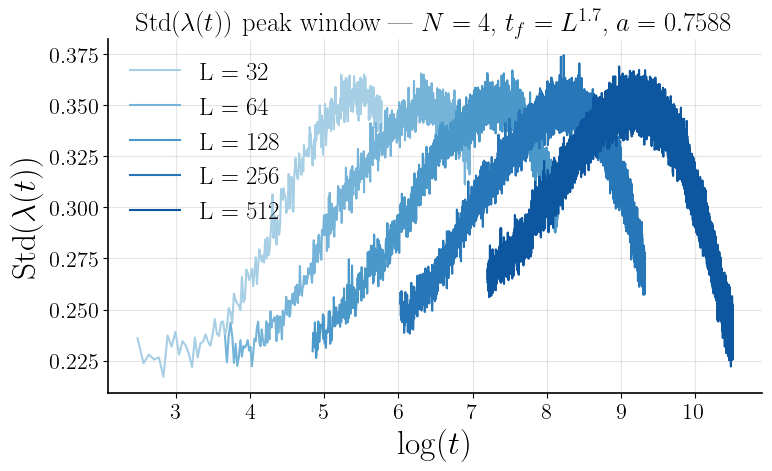

In [6]:

for a_val in a_vals:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(
        rf"$\mathrm{{Std}}(\lambda(t))$ peak window — $N={N_val}$, $t_f=L^{{{z_val}}}$, $a={a_val}$"
    )
    ax.set_xlabel(r"$\log(t)$")
    ax.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

    for i, num_unit_cells in enumerate(num_unit_cells_vals):
        L  = num_unit_cells * N_val
        c  = blue_colors[i]
        y  = collected_lambda_STD_series[L][a_val]
        T  = len(y)
        t0 = int(T * peak_frac_lims[0])
        t1 = int(T * peak_frac_lims[1])

        ax.plot(np.log(np.arange(t0, t1)), y[t0:t1],
                color=c, label=f"L = {L}")

    ax.legend()
    fig.tight_layout()
    plt.show()

---
## 8. Save Peak-Window Data for Collapse

In [7]:
a_vals_to_save = [0.7575]

for i, num_unit_cells in enumerate(num_unit_cells_vals):
    L = num_unit_cells * N_val
    for a_val in a_vals_to_save:
        y  = collected_lambda_STD_series[L][a_val]
        T  = len(y)
        t0 = int(T * peak_frac_lims[0])
        t1 = int(T * peak_frac_lims[1])

        data = {t: y[t] for t in range(t0, t1)}
        a_name = str(a_val).replace(".", "p")
        fp = (
            f"data_to_collapse/lambda_std_per_t/N{N_val}/a{a_name}/IC{num_initial_conds}/L{L}/"
            f"lambda_std_per_t_N{N_val}_a{a_name}_IC{num_initial_conds}_L{L}_z{z_val_name}.csv"
        )
        save_simple_dict_to_csv(data, fp)
        print(f"Saved: {fp}")

Saved: data_to_collapse/lambda_std_per_t/N4/a0p7575/IC1000/L32/lambda_std_per_t_N4_a0p7575_IC1000_L32_z1p7.csv
Saved: data_to_collapse/lambda_std_per_t/N4/a0p7575/IC1000/L64/lambda_std_per_t_N4_a0p7575_IC1000_L64_z1p7.csv
Saved: data_to_collapse/lambda_std_per_t/N4/a0p7575/IC1000/L128/lambda_std_per_t_N4_a0p7575_IC1000_L128_z1p7.csv
Saved: data_to_collapse/lambda_std_per_t/N4/a0p7575/IC1000/L256/lambda_std_per_t_N4_a0p7575_IC1000_L256_z1p7.csv
Saved: data_to_collapse/lambda_std_per_t/N4/a0p7575/IC1000/L512/lambda_std_per_t_N4_a0p7575_IC1000_L512_z1p7.csv


---
## 9. Collapsed Std(λ) vs t/L^z

In [8]:
a_vals

[0.7563, 0.7575, 0.7588]

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/LSeveral/zoomed_std_lambda_per_t_N4_a0p7588_IC1000_z1p7_col.png


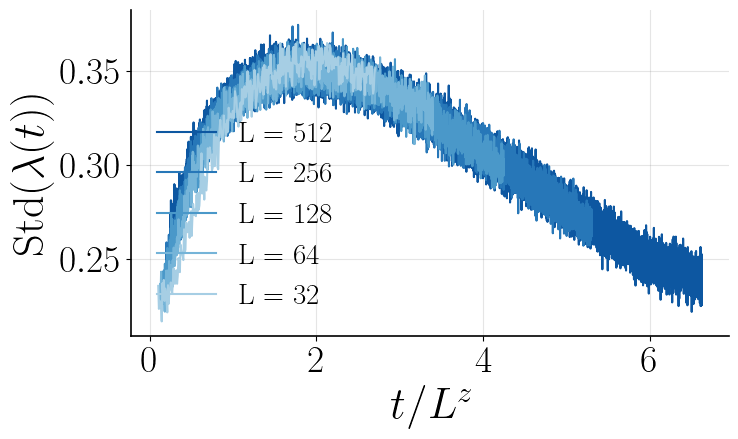

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/LSeveral/std_lambda_per_t_N4_a0p7588_IC1000_z1p7_col.png


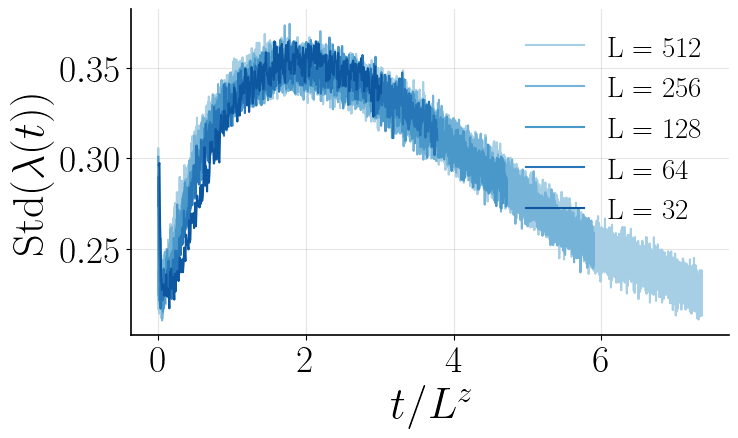

In [9]:

z_collapse_vals = {0.7563:1.15, 0.7575: 1.18, 0.7588:1.38}  # dynamical exponent used for collapse

plt.rcParams["font.size"] = 27
plt.rcParams["axes.labelsize"] = 32
plt.rcParams["legend.fontsize"] = 21

a_vals = [0.7588]

for a_val in a_vals:
    # ── Zoomed collapse (peak window only) ───────────────────────────────────────
    a_val_name = str(a_val).replace(".", "p")
    fig, ax = plt.subplots(figsize=(8, 5))
    # ax.set_title(
    #     rf"Collapsed $\mathrm{{Std}}(\lambda(t))$ — $N={N_val}$"
    #     rf", $t_f=L^{{{z_val}}}$, $z={z_collapse_vals[a_val]}$, $a={a_val}$"
    # )
    ax.set_xlabel(r"$t / L^z$")
    ax.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

    for i, num_unit_cells in enumerate(reversed(num_unit_cells_vals)):
        L = num_unit_cells * N_val
        c = blue_colors[len(num_unit_cells_vals) - i-1]
        
        y  = collected_lambda_STD_series[L][a_val]
        T  = len(y)
        t0 = int(T * peak_frac_lims[0])
        t1 = int(T * peak_frac_lims[1])
        ts = np.arange(t0, t1) / (L ** z_collapse_vals[a_val])
        ax.plot(ts, y[t0:t1], color=c, label=f"L = {L}")

    ax.legend()
    out = (
        f"figs/lambda_per_t/N{N_val}/a{a_val_name}/IC{num_initial_conds}/LSeveral/"
        f"zoomed_std_lambda_per_t_N{N_val}_a{a_val_name}"
        f"_IC{num_initial_conds}_z{z_val_name}_col.png"
    )
    make_path_exist(out)
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()

    # ── Full-range collapse ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    # ax.set_title(
    #     rf"Collapsed $\mathrm{{Std}}(\lambda(t))$ — $N={N_val}$"
    #     rf", $t_f=L^{{{z_val}}}$, $z={z_collapse_vals[a_val]}$, $a={a_val}$"
    # )
    ax.set_xlabel(r"$t / L^z$")
    ax.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

    for i, num_unit_cells in enumerate(reversed(num_unit_cells_vals)):
        L = num_unit_cells * N_val
        c = blue_colors[i]
        y  = collected_lambda_STD_series[L][a_val]
        T  = len(y)
        ts = np.arange(1, T + 1) / (L ** z_collapse_vals[a_val])
        ax.plot(ts, y, color=c, label=f"L = {L}")

    ax.legend()
    out = (
        f"figs/lambda_per_t/N{N_val}/a{a_val_name}/IC{num_initial_conds}/LSeveral/"
        f"std_lambda_per_t_N{N_val}_a{a_val_name}"
        f"_IC{num_initial_conds}_z{z_val_name}_col.png"
    )
    make_path_exist(out)
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()

---
## 10. Collapsed Std(λ) vs log(t/L^z)

Saved: figs/lambda_per_t/N4/a0p7563/IC1000/LSeveral/log_collapsed_std_lambda_per_t_N4_a0p7563_IC1000_z1p7.png


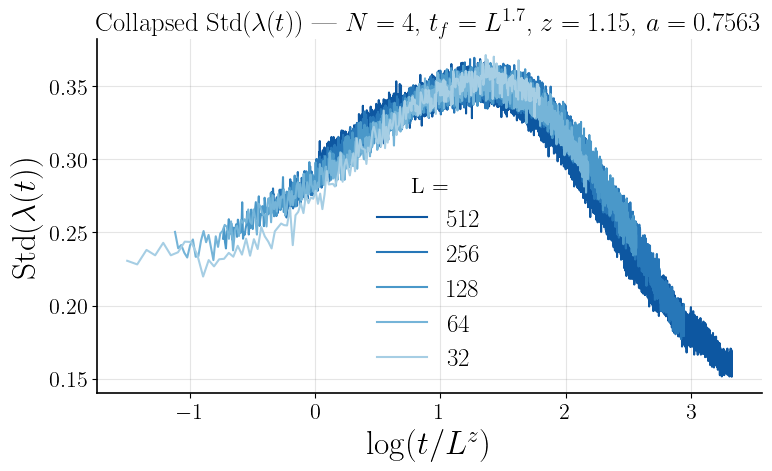

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/LSeveral/log_collapsed_std_lambda_per_t_N4_a0p7575_IC1000_z1p7.png


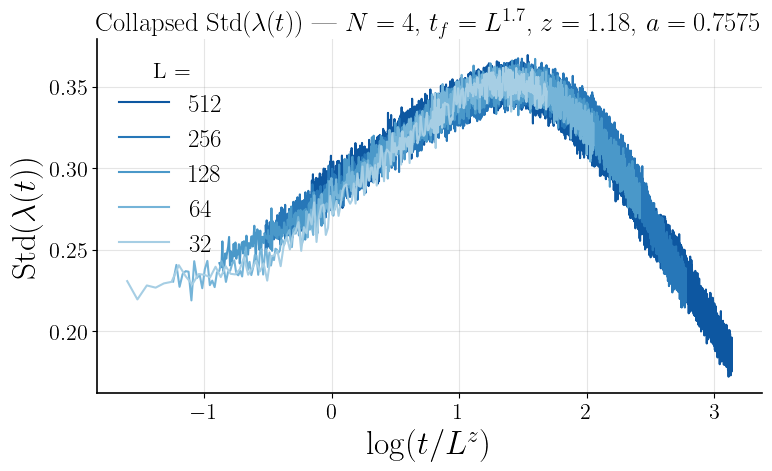

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/LSeveral/log_collapsed_std_lambda_per_t_N4_a0p7588_IC1000_z1p7.png


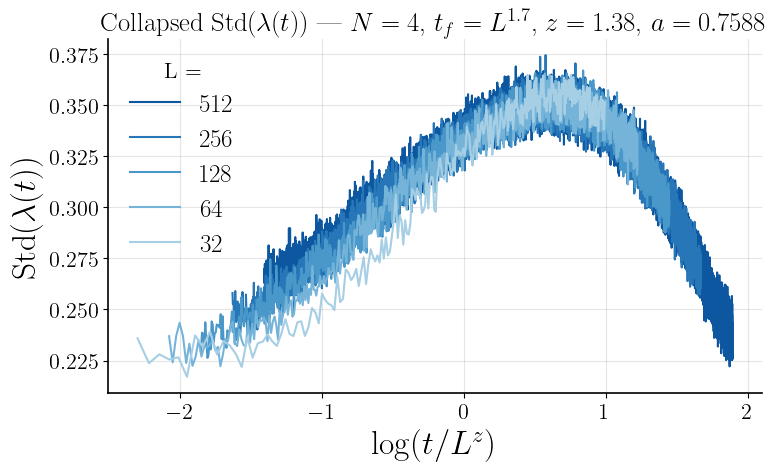

In [10]:
for a_val in a_vals:
    a_val_name = str(a_val).replace(".", "p")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(
        rf"Collapsed $\mathrm{{Std}}(\lambda(t))$ — $N={N_val}$"
        rf", $t_f=L^{{{z_val}}}$, $z={z_collapse_vals[a_val]}$, $a={a_val}$"
    )
    ax.set_xlabel(r"$\log(t / L^z)$")
    ax.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

    for i, num_unit_cells in enumerate(reversed(num_unit_cells_vals)):
        L = num_unit_cells * N_val
        c = blue_colors[len(num_unit_cells_vals)-i-1]
        
        y  = collected_lambda_STD_series[L][a_val]
        T  = len(y)
        t0 = int(T * peak_frac_lims[0])
        t1 = int(T * peak_frac_lims[1])
        # log(t) - log(L^z)  =  log(t / L^z)
        log_ts = np.log(np.arange(t0, t1)) - np.log(L ** z_collapse_vals[a_val])
        ax.plot(log_ts, y[t0:t1], color=c, label=f"{L}")

    ax.legend(title="L =")
    out = (
        f"figs/lambda_per_t/N{N_val}/a{a_val_name}/IC{num_initial_conds}/LSeveral/"
        f"log_collapsed_std_lambda_per_t_N{N_val}_a{a_val_name}"
        f"_IC{num_initial_conds}_z{z_val_name}.png"
    )
    make_path_exist(out)
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()

---
## 11. Publication Figure: log(t) Main Panel + Collapsed Inset


Saved: figs/lambda_per_t/N4/a0p7563/IC1000/LSeveral/inset_log_collapsed_std_lambda_per_t_N4_a0p7563_IC1000_z1p7.png


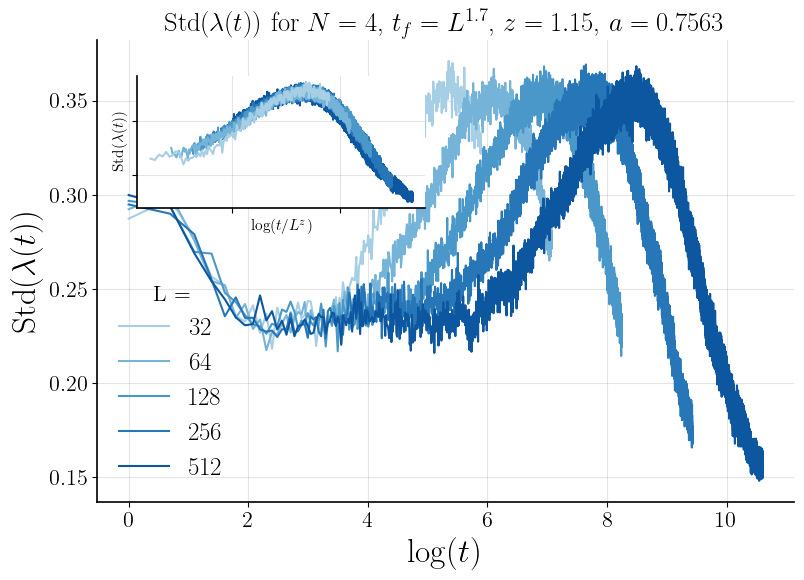

Saved: figs/lambda_per_t/N4/a0p7575/IC1000/LSeveral/inset_log_collapsed_std_lambda_per_t_N4_a0p7575_IC1000_z1p7.png


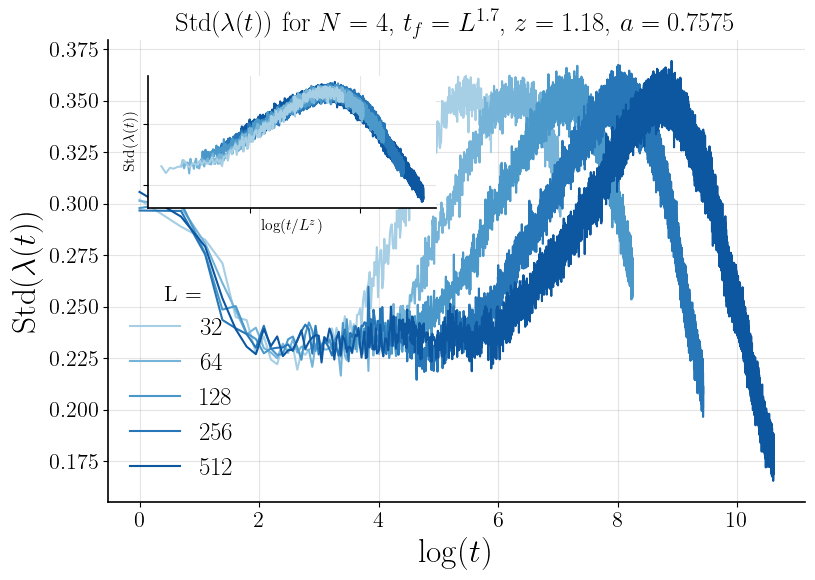

Saved: figs/lambda_per_t/N4/a0p7588/IC1000/LSeveral/inset_log_collapsed_std_lambda_per_t_N4_a0p7588_IC1000_z1p7.png


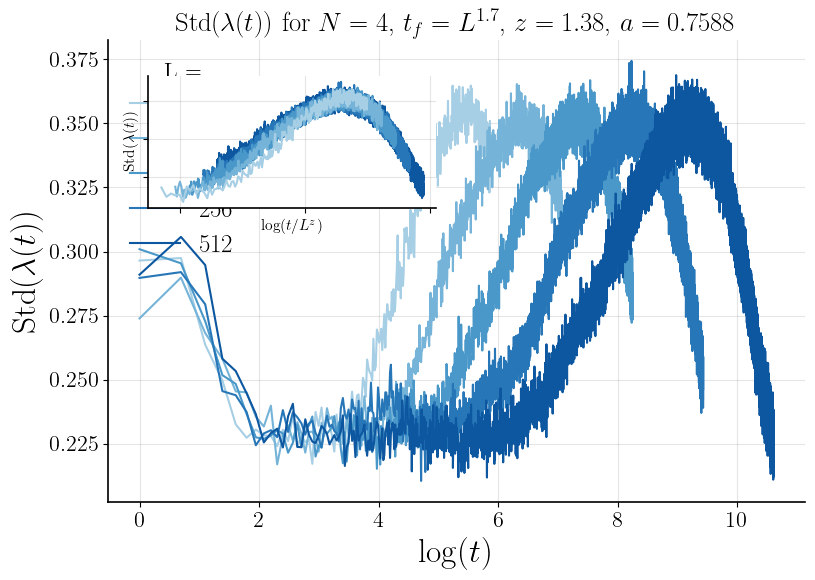

In [11]:

for a_val in a_vals:
    a_val_name = str(a_val).replace(".", "p")
    # Re-draw the main log(t) panel so we can safely add the inset
    fig_pub, ax_pub = plt.subplots(figsize=(9, 6))
    ax_pub.set_title(
        rf"$\mathrm{{Std}}(\lambda(t))$ for $N={N_val}$, $t_f = L^{{{z_val}}}$, $z={z_collapse_vals[a_val]}$, $a={a_val}$"
    )
    ax_pub.set_xlabel(r"$\log(t)$")
    ax_pub.set_ylabel(r"$\mathrm{Std}(\lambda(t))$")

    for i, num_unit_cells in enumerate(num_unit_cells_vals):
        L = num_unit_cells * N_val
        c = blue_colors[i]
        y = collected_lambda_STD_series[L][a_val]
        ax_pub.plot(np.log(np.arange(1, len(y) + 1)), y, color=c, label=str(L))

    ax_pub.legend(title="L =")

    # ── Inset: collapsed log(t/L^z) ──────────────────────────────────────────────
    inset_rect = [0.17, 0.6, 0.32, 0.22]   
    ax_in = fig_pub.add_axes(inset_rect)
    ax_in.tick_params(labelleft=False, labelbottom=False)
    ax_in.set_xlabel(r"$\log(t / L^z)$", fontsize=11)
    ax_in.set_ylabel(r"$\mathrm{Std}(\lambda(t))$", fontsize=11)

    for i, num_unit_cells in enumerate(reversed(num_unit_cells_vals)):
        L = num_unit_cells * N_val
        c = blue_colors[len(num_unit_cells_vals)-i-1]
        y  = collected_lambda_STD_series[L][a_val]
        T  = len(y)
        t0 = int(T * peak_frac_lims[0])
        t1 = int(T * peak_frac_lims[1])
        log_ts = np.log(np.arange(t0, t1)) - np.log(L ** z_collapse_vals[a_val])
        ax_in.plot(log_ts, y[t0:t1], color=c)

    out = (
        f"figs/lambda_per_t/N{N_val}/a{a_val_name}/IC{num_initial_conds}/LSeveral/"
        f"inset_log_collapsed_std_lambda_per_t_N{N_val}_a{a_val_name}"
        f"_IC{num_initial_conds}_z{z_val_name}.png"
    )
    make_path_exist(out)
    fig_pub.savefig(out, dpi=150)
    print(f"Saved: {out}")
    plt.show()

# Conclusion
$z \approx 1.2 \pm 0.2$

In [12]:
#